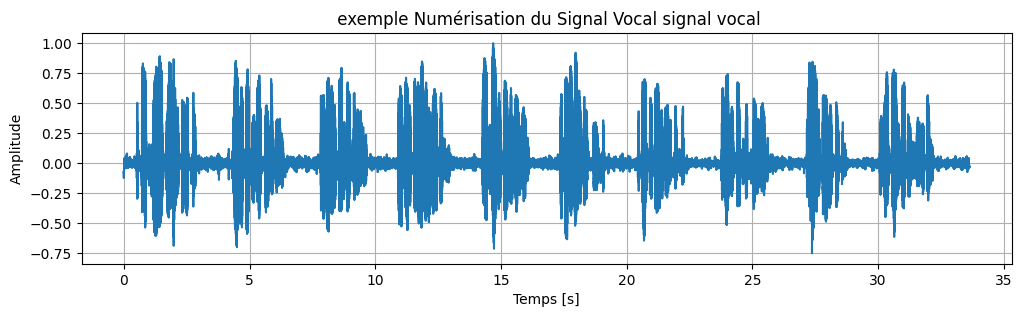

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav

fs, signal = wav.read('femme.wav')
signal = signal / np.max(np.abs(signal))  # Normalisation

plt.figure(figsize=(12, 3))
plt.plot(np.linspace(0, len(signal)/fs, len(signal)), signal)
plt.title(" exemple Numérisation du Signal Vocal signal vocal")
plt.xlabel("Temps [s]")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


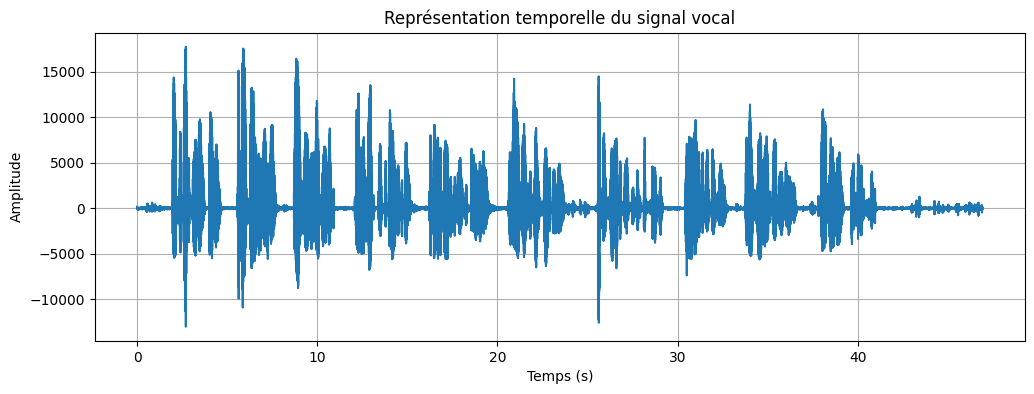

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Charger un fichier audio
fs, signal = wavfile.read('homme.wav')

# Créer un vecteur temps en secondes
duration = len(signal) / fs
time = np.linspace(0, duration, len(signal))

# Afficher la forme d'onde
plt.figure(figsize=(12, 4))
plt.plot(time, signal)
plt.title('Représentation temporelle du signal vocal')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


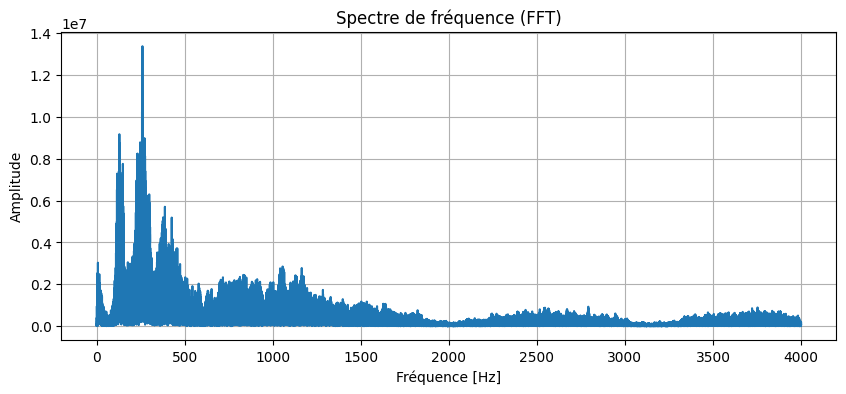

In [10]:
from scipy.fft import fft

n = len(signal)
frequencies = np.fft.fftfreq(n, 1/fs)
spectrum = np.abs(fft(signal))

plt.figure(figsize=(10, 4))
plt.plot(frequencies[:n//2], spectrum[:n//2])
plt.title("Spectre de fréquence (FFT)")
plt.xlabel("Fréquence [Hz]")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


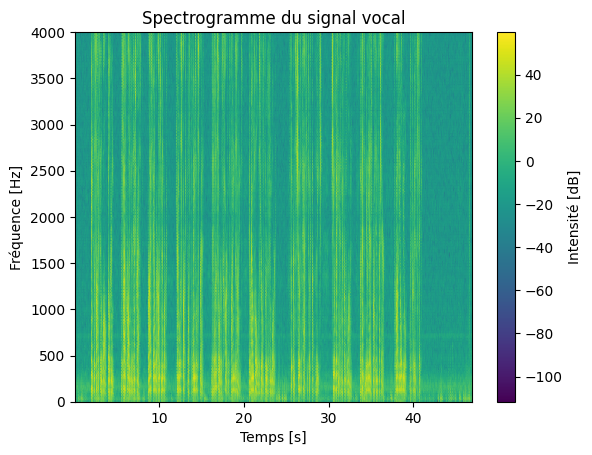

In [11]:
from scipy.signal import spectrogram

f, t, Sxx = spectrogram(signal, fs)
plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
plt.title("Spectrogramme du signal vocal")
plt.ylabel("Fréquence [Hz]")
plt.xlabel("Temps [s]")
plt.colorbar(label='Intensité [dB]')
plt.show()


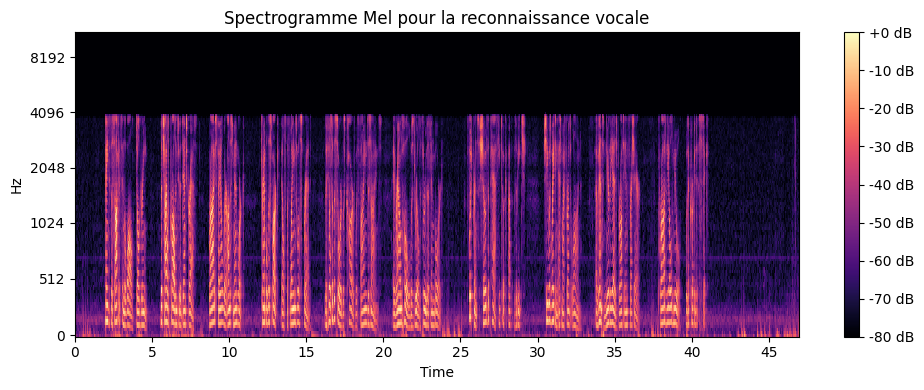

In [15]:
import librosa.display
y, sr = librosa.load('homme.wav')
plt.figure(figsize=(10, 4))
S = librosa.feature.melspectrogram(y=y, sr=sr)
S_dB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
plt.title('Spectrogramme Mel pour la reconnaissance vocale')
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()


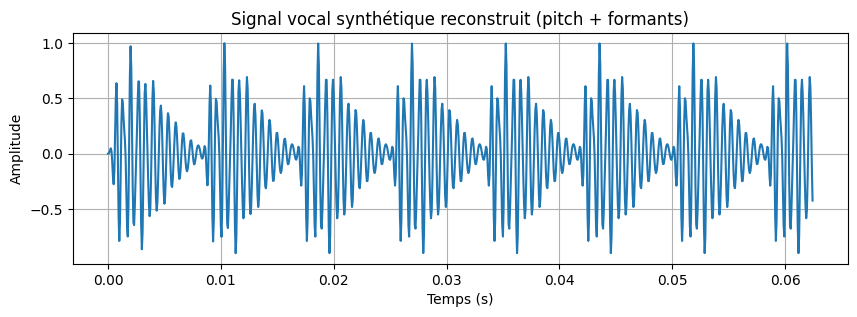

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

# Paramètres
fs = 16000             # Fréquence d'échantillonnage
duration = 1.0         # Durée en secondes
f0 = 120               # Pitch (Hz)
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# Signal source : train d'impulsions (glottal pulses)
source = np.zeros_like(t)
source[::int(fs / f0)] = 1  # impulsions périodiques

# Formants simulés (résonances)
# Exemple de filtre passe-bande simplifié (3 formants)
from scipy.signal import butter
def formant_filter(signal, f_center, Q=20):
    b, a = butter(2, [f_center - f_center/Q, f_center + f_center/Q], btype='band', fs=fs)
    return lfilter(b, a, signal)

# Appliquer les filtres formants (F1 = 500 Hz, F2 = 1500 Hz, F3 = 2500 Hz)
filtered = formant_filter(source, 500)
filtered = formant_filter(filtered, 1500)
filtered = formant_filter(filtered, 2500)

# Normalisation
filtered = filtered / np.max(np.abs(filtered))

# Affichage
plt.figure(figsize=(10, 3))
plt.plot(t[:1000], filtered[:1000])
plt.title("Signal vocal synthétique reconstruit (pitch + formants)")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


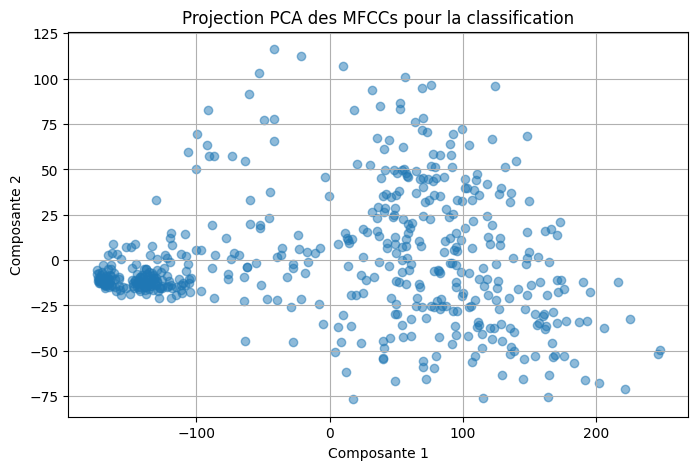

In [19]:
import librosa
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Charger un fichier audio (remplace 'parole.wav' par ton vrai fichier)
y, sr = librosa.load("femme.wav", sr=None)  # sr=None pour garder le taux original

# Calcul des MFCCs
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

# PCA sur les MFCCs
X = mfccs.T
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Affichage
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title("Projection PCA des MFCCs pour la classification")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.grid(True)
plt.show()

